# Proyecto de Consultoría ante Hackeo
## Laboratorio 12

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, count, when, isnan, corr, max as spark_max, min as spark_min, mean
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Corrección de errores para spark

In [4]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark

In [5]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

## Iniciar sesión de Spark

In [60]:
import findspark
findspark.init()

spark = SparkSession.builder \
    .appName("Lab Spark Hacking") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

print("Spark session iniciada correctamente")
print("Spark version:", spark.version)

Spark session iniciada correctamente
Spark version: 3.5.0


## Cargar los datos

In [8]:
df_hack = spark.read.csv(
    'hack_data.csv',
    header=True,
    inferSchema=True
)

## **Análisis de datos**

In [9]:
# Contar registros
total_registros = df_hack.count()
print(f"Total de datos en el dataset: {total_registros}")

Total de datos en el dataset: 334


In [10]:
df_hack.printSchema()

root
 |-- Session_Connection_Time: double (nullable = true)
 |-- Bytes Transferred: double (nullable = true)
 |-- Kali_Trace_Used: integer (nullable = true)
 |-- Servers_Corrupted: double (nullable = true)
 |-- Pages_Corrupted: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- WPM_Typing_Speed: double (nullable = true)



In [11]:
df_hack.describe().show()

+-------+-----------------------+------------------+------------------+-----------------+------------------+-----------+------------------+
|summary|Session_Connection_Time| Bytes Transferred|   Kali_Trace_Used|Servers_Corrupted|   Pages_Corrupted|   Location|  WPM_Typing_Speed|
+-------+-----------------------+------------------+------------------+-----------------+------------------+-----------+------------------+
|  count|                    334|               334|               334|              334|               334|        334|               334|
|   mean|     30.008982035928145| 607.2452694610777|0.5119760479041916|5.258502994011977|10.838323353293413|       NULL|57.342395209580864|
| stddev|     14.088200614636158|286.33593163576757|0.5006065264451406| 2.30190693339697|  3.06352633036022|       NULL| 13.41106336843464|
|    min|                    1.0|              10.0|                 0|              1.0|               6.0|Afghanistan|              40.0|
|    max|           

In [14]:
# Verificar valores nulos
print("Análisis de Valores Nulos:")
df_hack.select([count(when(col(c).isNull() | isnan(c), c)).alias(c)
                   for c in df_hack.columns]).show()

Análisis de Valores Nulos:
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+
|Session_Connection_Time|Bytes Transferred|Kali_Trace_Used|Servers_Corrupted|Pages_Corrupted|Location|WPM_Typing_Speed|
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+
|                      0|                0|              0|                0|              0|       0|               0|
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+



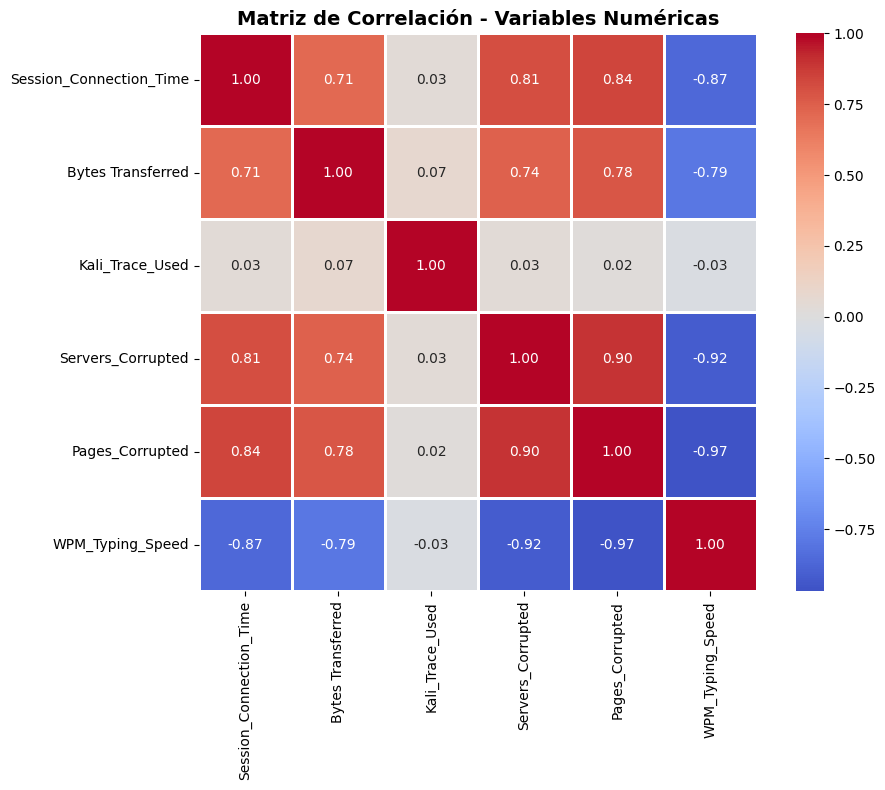

In [38]:
# Seleccionar solo variables a usar por el momento
# Debido al uso de VPNs Location no es una variable que aporte información relevante
toUse_cols = ["Session_Connection_Time","Bytes Transferred","Kali_Trace_Used","Servers_Corrupted","Pages_Corrupted","WPM_Typing_Speed"]

# Convertir a Pandas para análisis de correlación más fácil
df_pandas = df_hack.select(toUse_cols).toPandas()

# Matriz de correlación
correlation_matrix = df_pandas.corr()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()

In [18]:
# Identificar multicolinealidad (correlaciones altas entre predictores)
print("Análisis de Multicolinealidad:")
print("Pares de variables con correlación > 0.9:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            print(f"  - {correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: "
                  f"{correlation_matrix.iloc[i, j]:.3f}")

Análisis de Multicolinealidad:
Pares de variables con correlación > 0.9:
  - Servers_Corrupted vs WPM_Typing_Speed: -0.916
  - Pages_Corrupted vs WPM_Typing_Speed: -0.969


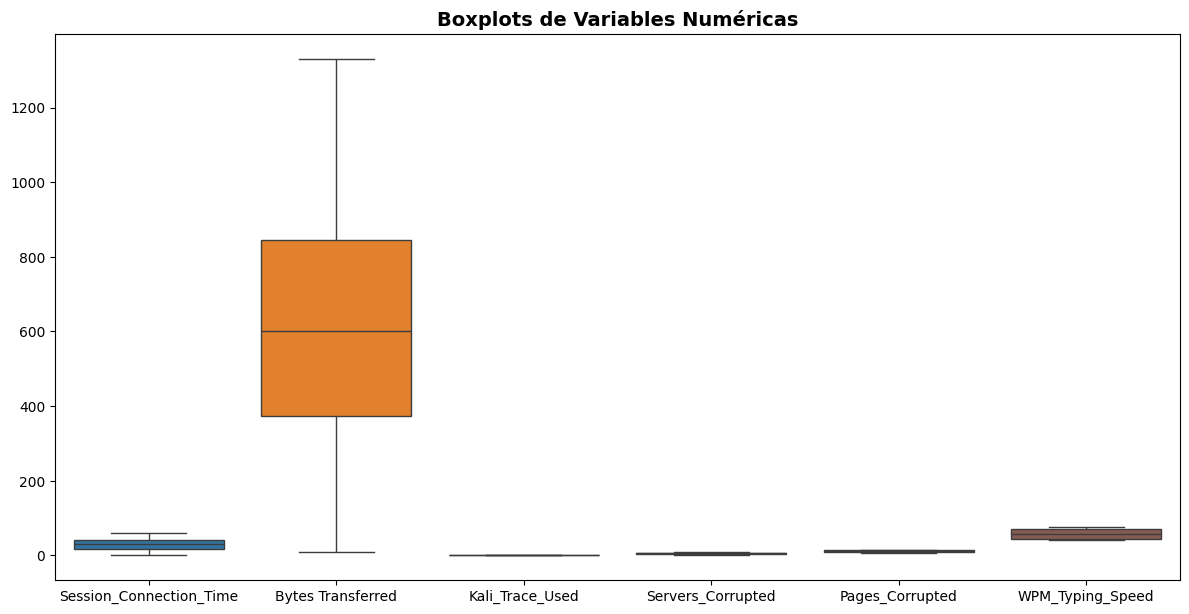

In [34]:
# Verificación de outliers
plt.figure(figsize=(12, 6))  # ajusta ancho x alto
sns.boxplot(data=df_pandas)
plt.tight_layout()
plt.title('Boxplots de Variables Numéricas', fontsize=14, fontweight='bold')
plt.show()

## preprocesamiento

In [45]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(df_pandas.drop(columns=['WPM_Typing_Speed']))

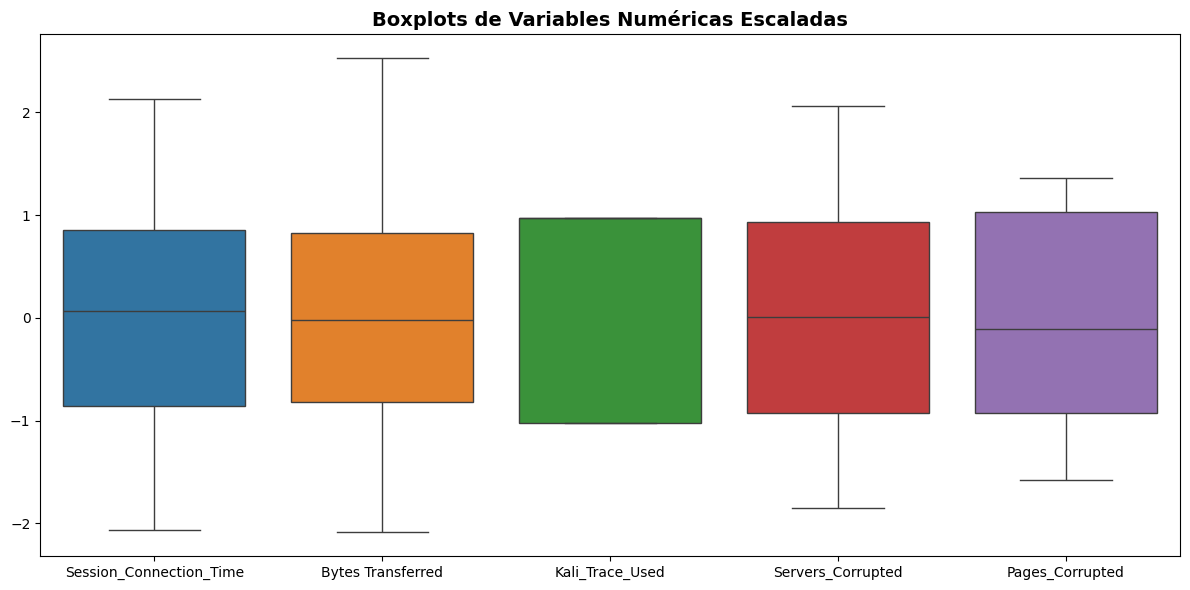

In [48]:
df_scaled = pd.DataFrame(
    scaled,
    columns=df_pandas.drop(columns=['WPM_Typing_Speed']).columns
)

# visualización de datos escalados
plt.figure(figsize=(12,6))
sns.boxplot(data=df_scaled)
plt.title('Boxplots de Variables Numéricas Escaladas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# Convertir el df procesado de pandas a spark
df = spark.createDataFrame(df_scaled)

In [59]:
# Describir variables escaladas
df.describe().show()

+-------+-----------------------+--------------------+--------------------+--------------------+--------------------+
|summary|Session_Connection_Time|   Bytes Transferred|     Kali_Trace_Used|   Servers_Corrupted|     Pages_Corrupted|
+-------+-----------------------+--------------------+--------------------+--------------------+--------------------+
|  count|                    334|                 334|                 334|                 334|                 334|
|   mean|   -1.70189876828766...|-8.50949384143832...|7.97765047634843E-18|-8.50949384143832...|-8.50949384143832...|
| stddev|     1.0015003759375245|  1.0015003759375247|  1.0015003759375252|  1.0015003759375247|  1.0015003759375245|
|    min|    -2.0621871599673574|  -2.088949711882618|   -1.02424594439091| -1.8527648913851973| -1.5817009990121091|
|    max|     2.1319980164509253|   2.529685605279595|   0.976328005472037|  2.0629031370073827|   1.360497765239376|
+-------+-----------------------+--------------------+--

## **Clustering**

In [57]:
# lista de variables usadas
feature_cols = df_scaled.columns